# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

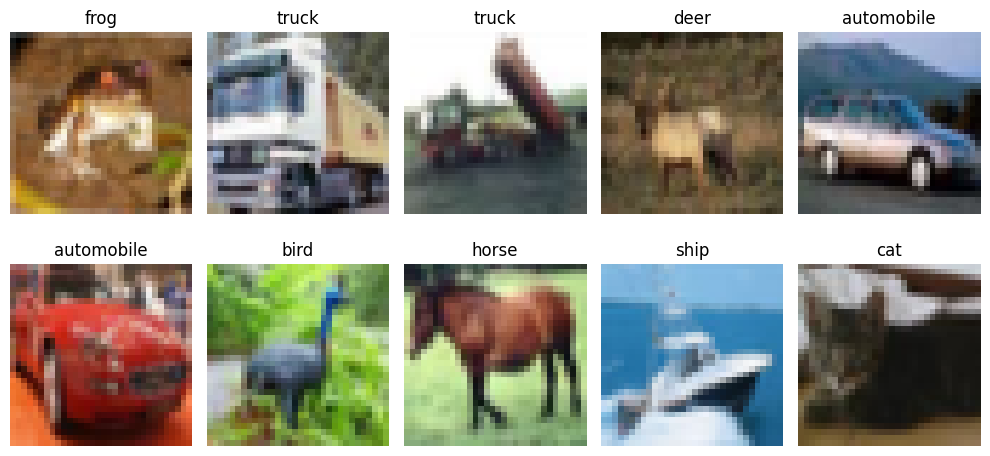

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.2653 - loss: 2.0082 - val_accuracy: 0.3206 - val_loss: 1.8534
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3159 - loss: 1.8711 - val_accuracy: 0.3236 - val_loss: 1.8398
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3388 - loss: 1.8189 - val_accuracy: 0.3830 - val_loss: 1.7423
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3584 - loss: 1.7676 - val_accuracy: 0.3900 - val_loss: 1.7573
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3654 - loss: 1.7488 - val_accuracy: 0.4030 - val_loss: 1.7045
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 37ms/step - accuracy: 0.3748 - loss: 1.7307 - val_accuracy: 0.4242 - val_loss: 1.6995
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.3833 - loss: 1.7112 - val_accuracy: 0.4042 - val_loss: 1.6820
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3809 - loss: 1.7057 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4374 - loss: 1.6094
ANN Test Accuracy: 0.4374000132083893


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 134ms/step - accuracy: 0.4724 - loss: 1.4839 - val_accuracy: 0.5730 - val_loss: 1.2408
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.6112 - loss: 1.1136 - val_accuracy: 0.6544 - val_loss: 0.9865
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.6779 - loss: 0.9328 - val_accuracy: 0.6406 - val_loss: 1.0297
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7149 - loss: 0.8219 - val_accuracy: 0.6736 - val_loss: 0.9102
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.7458 - loss: 0.7265 - val_accuracy: 0.7240 - val_loss: 0.8140
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 136ms/step - accuracy: 0.7726 - loss: 0.6476 - val_accuracy: 0.6852 - val_loss: 1.0026
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 134ms/step - accuracy: 0.7970 - loss: 0.5818 - val_accuracy: 0.7298 - val_loss: 0.8272
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.8144 - loss: 0

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7265 - loss: 0.9134
CNN Test Accuracy: 0.7264999747276306


## 📈 Compare Learning Curves

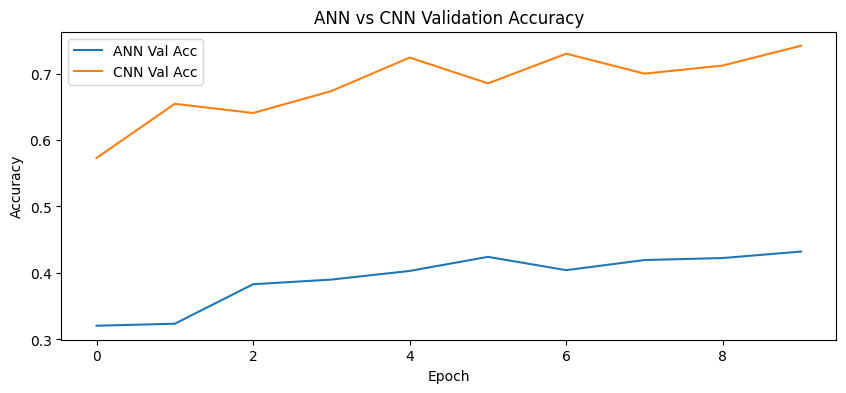

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# Evaluate so aug_test_acc is available for the comparison table
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 54ms/step - accuracy: 0.3664 - loss: 1.7314 - val_accuracy: 0.4804 - val_loss: 1.4344
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.4608 - loss: 1.4948 - val_accuracy: 0.5332 - val_loss: 1.2790
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 86s 56ms/step - accuracy: 0.4977 - loss: 1.3963 - val_accuracy: 0.5544 - val_loss: 1.2443
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 54ms/step - accuracy: 0.5250 - loss: 1.3340 - val_accuracy: 0.5686 - val_loss: 1.2122
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.5459 - loss: 1.2886 - val_accuracy: 0.6092 - val_loss: 1.1053
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.5551 - loss: 1.2581 - val_accuracy: 0.5884 - val_loss: 1.1551
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.5648 - loss: 1.2315 - val_accuracy: 0.6478 - val_loss: 1.0189
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.5694 -

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4374
1,CNN,0.7265
2,Augmented CNN,0.6455


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

## ✅ Task 1: Increase ANN Layers (Deeper ANN)

### 🎯 Objective
Understand whether adding more Dense layers to an ANN improves its performance on image classification.

### 🔧 What We Changed
- **Baseline ANN** had 2 hidden layers: Dense(512) → Dense(256)
- **Deep ANN** has 4 hidden layers: Dense(512) → Dense(256) → Dense(128) → Dense(64)
- Added extra Dropout layers after each new Dense layer to prevent overfitting

### 📌 Why We Did This
More layers give the model more capacity to learn complex patterns. We want to test if making the ANN deeper can help it compete with CNN on image data.

### 📊 Expected Outcome
Accuracy improves slightly but still stays well below CNN. The reason is that **depth alone cannot fix the core limitation** — flattening a 32×32 image into 3072 numbers destroys all spatial structure (which pixel is next to which), and no amount of Dense layers can recover that lost information.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.2236 - loss: 2.0682 - val_accuracy: 0.2734 - val_loss: 1.9556
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.2909 - loss: 1.9202 - val_accuracy: 0.3338 - val_loss: 1.8562
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3078 - loss: 1.8785 - val_accuracy: 0.3420 - val_loss: 1.8388
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3155 - loss: 1.8620 - val_accuracy: 0.3372 - val_loss: 1.8055
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.3221 - loss: 1.8414 - val_accuracy: 0.3430 - val_loss: 1.8034
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3304 - loss: 1.8244 - val_accuracy: 0.3690 - val_loss: 1.7759
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.3376 - loss: 1.8108 - val_accuracy: 0.3690 - val_loss: 1.7558
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.3361 - loss: 1.8059 - 

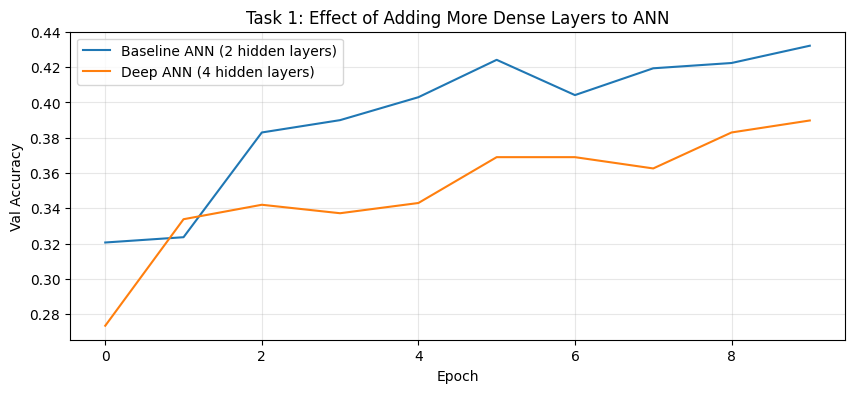

Baseline ANN : 0.4374
Deep ANN     : 0.3946
Change       : -4.28%


In [13]:
deep_ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),   # new layer
    layers.Dropout(0.2),
    layers.Dense(64,  activation='relu'),   # new layer
    layers.Dense(10,  activation='softmax')
])
deep_ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
deep_ann_history = deep_ann_model.fit(x_train_flat, y_train, epochs=10, validation_split=0.1, batch_size=64)
_, deep_ann_acc = deep_ann_model.evaluate(x_test_flat, y_test, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'],      label='Baseline ANN (2 hidden layers)')
plt.plot(deep_ann_history.history['val_accuracy'], label='Deep ANN (4 hidden layers)')
plt.title("Task 1: Effect of Adding More Dense Layers to ANN")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print(f"Baseline ANN : {ann_test_acc:.4f}")
print(f"Deep ANN     : {deep_ann_acc:.4f}")
print(f"Change       : {(deep_ann_acc - ann_test_acc)*100:+.2f}%")

## ✅ Task 2: Scale CNN Filters 32 → 64 → 128

### 🎯 Objective
Understand how progressively increasing the number of Conv2D filters affects feature extraction and model accuracy.

### 🔧 What We Changed
- Built a CNN with **3 Conv2D blocks** where each block doubles the filter count
- Block 1: **32 filters** — detects simple edges and colors
- Block 2: **64 filters** — detects shapes and textures
- Block 3: **128 filters** — detects complex object parts
- Added `padding='same'` so feature map sizes don't shrink too quickly

### 📌 Why We Did This
Each Conv2D layer builds on top of the previous one. More filters at deeper layers allow the model to learn richer and more complex visual features, which is key for distinguishing between 10 different object classes.

### 📊 Expected Outcome
This CNN should match or slightly outperform the baseline CNN. The explicit 32 → 64 → 128 progression ensures the model has increasing capacity to detect progressively complex features at each stage.

In [14]:
scaled_cnn = models.Sequential([
    layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,  (3,3), activation='relu', padding='same'),   # doubled
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),   # doubled again
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,  activation='softmax')
])
scaled_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
scaled_cnn.fit(x_train_norm, y_train, epochs=10, validation_split=0.1, batch_size=64)
_, scaled_cnn_acc = scaled_cnn.evaluate(x_test_norm, y_test, verbose=0)
print(f"Baseline CNN accuracy       : {cnn_test_acc:.4f}")
print(f"Scaled CNN (32→64→128) acc  : {scaled_cnn_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 213ms/step - accuracy: 0.4322 - loss: 1.5868 - val_accuracy: 0.4506 - val_loss: 1.7323
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 196s 204ms/step - accuracy: 0.6013 - loss: 1.1434 - val_accuracy: 0.4778 - val_loss: 1.7578
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 218ms/step - accuracy: 0.6706 - loss: 0.9441 - val_accuracy: 0.5854 - val_loss: 1.3468
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 155s 220ms/step - accuracy: 0.7198 - loss: 0.8059 - val_accuracy: 0.7096 - val_loss: 0.8802
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 157s 223ms/step - accuracy: 0.7526 - loss: 0.6978 - val_accuracy: 0.6770 - val_loss: 0.9753
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 154s 218ms/step - accuracy: 0.7843 - loss: 0.6117 - val_accuracy: 0.7162 - val_loss: 0.8480
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 207ms/step - accuracy: 0.8129 - loss: 0.5298 - val_accuracy: 0.6870 - val_loss: 1.0278
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 193ms/step - accuracy: 0.8349 -

## ✅ Task 3: Increase Training to 20 Epochs

### 🎯 Objective
Observe how training for longer affects model accuracy and whether overfitting begins to appear.

### 🔧 What We Changed
- Kept the same CNN architecture as the baseline
- Changed `epochs=10` to `epochs=20`
- Plotted both the 10-epoch and 20-epoch validation curves together for direct comparison

### 📌 Why We Did This
10 epochs may not be enough for the model to fully converge. Training longer gives the model more opportunities to adjust its weights. However, training too long can cause **overfitting** — where the model memorizes training data but performs worse on new images.

### 📊 Expected Outcome
- Validation accuracy improves in the first few extra epochs
- Around epoch 15–20, the validation curve may flatten or dip while training accuracy keeps rising
- This gap between training and validation accuracy is the sign of overfitting beginning

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 118ms/step - accuracy: 0.4747 - loss: 1.4787 - val_accuracy: 0.4968 - val_loss: 1.3904
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 152s 132ms/step - accuracy: 0.6141 - loss: 1.1116 - val_accuracy: 0.6530 - val_loss: 1.0131
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 137ms/step - accuracy: 0.6728 - loss: 0.9364 - val_accuracy: 0.6756 - val_loss: 0.9297
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 134ms/step - accuracy: 0.7142 - loss: 0.8158 - val_accuracy: 0.6768 - val_loss: 0.9768
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 134ms/step - accuracy: 0.7470 - loss: 0.7247 - val_accuracy: 0.6282 - val_loss: 1.1455
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 130s 117ms/step - accuracy: 0.7700 - loss: 0.6486 - val_accuracy: 0.6864 - val_loss: 0.9809
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 116ms/step - accuracy: 0.7935 - loss: 0.5872 - val_accuracy: 0.7336 - val_loss: 0.8387
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.8122 - loss

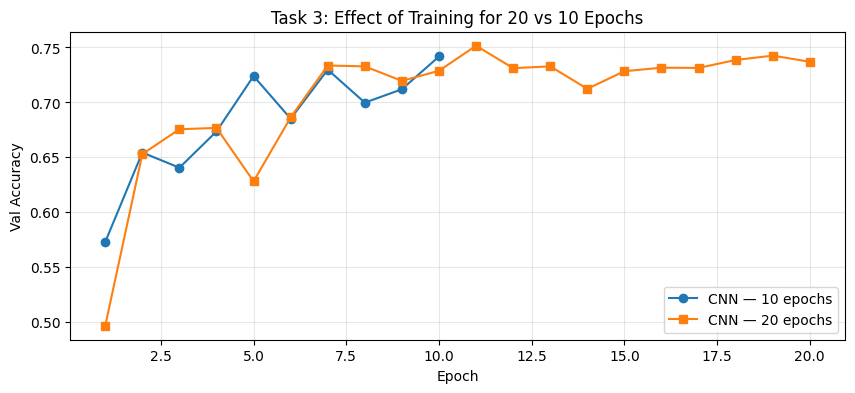

CNN 10 epochs : 0.7265
CNN 20 epochs : 0.7186


In [15]:
cnn_20ep = models.Sequential([
    layers.Conv2D(32,  (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(), layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,  (3,3), activation='relu'),
    layers.BatchNormalization(), layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.4),
    layers.Dense(10,  activation='softmax')
])
cnn_20ep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_20ep = cnn_20ep.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64)
_, acc_20ep = cnn_20ep.evaluate(x_test_norm, y_test, verbose=0)

plt.figure(figsize=(10,4))
plt.plot(range(1,11), cnn_history.history['val_accuracy'],  marker='o', label='CNN — 10 epochs')
plt.plot(range(1,21), history_20ep.history['val_accuracy'], marker='s', label='CNN — 20 epochs')
plt.title("Task 3: Effect of Training for 20 vs 10 Epochs")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print(f"CNN 10 epochs : {cnn_test_acc:.4f}")
print(f"CNN 20 epochs : {acc_20ep:.4f}")

## ✅ Task 4: Add EarlyStopping

### 🎯 Objective
Automatically stop training at the best point to prevent overfitting and avoid wasting compute time.

### 🔧 What We Changed
- Added `EarlyStopping` callback with these settings:
  - `monitor='val_loss'` — watches validation loss after every epoch
  - `patience=3` — stops training if val_loss does not improve for 3 consecutive epochs
  - `restore_best_weights=True` — automatically rolls back model weights to the best epoch
- Set `epochs=50` as a high ceiling so EarlyStopping decides when to stop

### 📌 Why We Did This
As we saw in Task 3, training too long leads to overfitting. EarlyStopping solves this automatically — it acts like a smart checkpoint that saves the best version of the model and stops training before the model starts getting worse.

### 📊 Expected Outcome
- Training stops well before epoch 50
- The printed output will show exactly which epoch it stopped at
- Final accuracy is at least as good as the 10-epoch baseline, achieved with fewer wasted epochs
- `restore_best_weights=True` ensures we always get the best checkpoint, not the last one

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',          # watch validation loss
    patience=3,                  # stop after 3 epochs of no improvement
    restore_best_weights=True,   # roll back to the best epoch
    verbose=1
)

cnn_early = models.Sequential([
    layers.Conv2D(32,  (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(), layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,  (3,3), activation='relu'),
    layers.BatchNormalization(), layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.4),
    layers.Dense(10,  activation='softmax')
])
cnn_early.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_early = cnn_early.fit(
    x_train_norm, y_train,
    epochs=50,                    # high ceiling — EarlyStopping cuts it short
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)
_, acc_early = cnn_early.evaluate(x_test_norm, y_test, verbose=0)
print(f"Training stopped at epoch : {len(history_early.history['val_loss'])} / 50")
print(f"EarlyStopping CNN Accuracy: {acc_early:.4f}")

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 138ms/step - accuracy: 0.4747 - loss: 1.4762 - val_accuracy: 0.4662 - val_loss: 1.5680
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 144ms/step - accuracy: 0.6190 - loss: 1.0967 - val_accuracy: 0.5510 - val_loss: 1.3174
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 141ms/step - accuracy: 0.6828 - loss: 0.9127 - val_accuracy: 0.5842 - val_loss: 1.3119
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.7217 - loss: 0.8056 - val_accuracy: 0.6884 - val_loss: 0.9367
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 136ms/step - accuracy: 0.7533 - loss: 0.7056 - val_accuracy: 0.6822 - val_loss: 0.9015
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 135ms/step - accuracy: 0.7804 - loss: 0.6251 - val_accuracy: 0.6858 - val_loss: 0.9421
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 137ms/step - accuracy: 0.8049 - loss: 0.5562 - val_accuracy: 0.7080 - val_loss: 0.9367
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 134ms/step - accuracy: 0.8233 - l

## ✅ Task 5: Run Augmented CNN Training

### 🎯 Objective
Improve model generalization by training on artificially varied versions of the training images using data augmentation.

### 🔧 What We Changed
Added a data augmentation pipeline at the start of the CNN using three techniques:
- `RandomFlip("horizontal")` — randomly mirrors images left-to-right (a cat facing left is still a cat)
- `RandomRotation(0.1)` — randomly rotates images slightly (up to ~36°) so the model isn't sensitive to tilt
- `RandomZoom(0.1)` — randomly zooms in or out by 10% to simulate different distances

The augmentation only applies **during training**, not during evaluation.

### 📌 Why We Did This
The model should recognize objects regardless of their orientation, position, or distance in an image. Without augmentation, the model only sees each image in one fixed form. Augmentation artificially creates variety from the same dataset, helping the model become more robust.

### 📊 Expected Outcome
- Training accuracy may be slightly **lower** than baseline CNN (harder augmented data is more challenging to learn)
- Test accuracy should be **higher or equal** (better generalization to unseen images)
- The validation curve is usually smoother and more stable compared to the baseline CNN

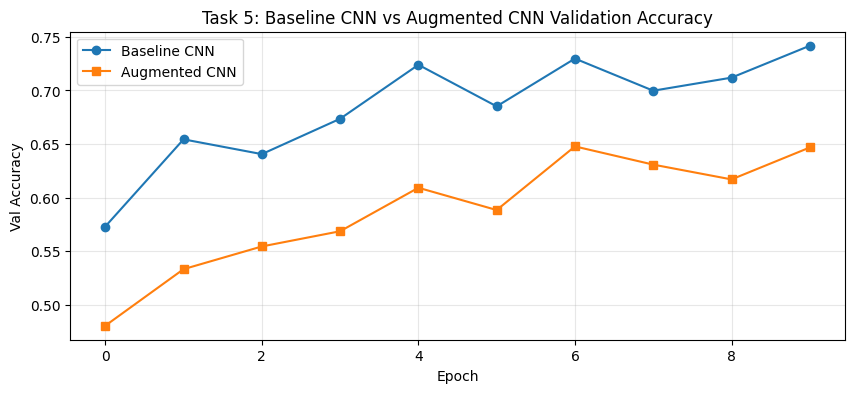

Baseline CNN   : 0.7265
Augmented CNN  : 0.6455
Change         : -8.10%


In [17]:
# Augmented CNN was already trained in the Data Augmentation cell above.
# Here we visualize and compare the results.

plt.figure(figsize=(10,4))
plt.plot(cnn_history.history['val_accuracy'], marker='o', label='Baseline CNN')
plt.plot(aug_history.history['val_accuracy'], marker='s', label='Augmented CNN')
plt.title("Task 5: Baseline CNN vs Augmented CNN Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print(f"Baseline CNN   : {cnn_test_acc:.4f}")
print(f"Augmented CNN  : {aug_test_acc:.4f}")
print(f"Change         : {(aug_test_acc - cnn_test_acc)*100:+.2f}%")